C:\Users\Usuario\AppData\Local\Temp\ipykernel_41540\3543207562.py:26: MatplotlibDeprecationWarning: The seaborn styles shipped by Matplotlib are deprecated since 3.6, as they no longer correspond to the styles shipped by seaborn. However, they will remain available as 'seaborn-v0_8-<style>'. Alternatively, directly use the seaborn API instead.
  plt.style.use('seaborn')


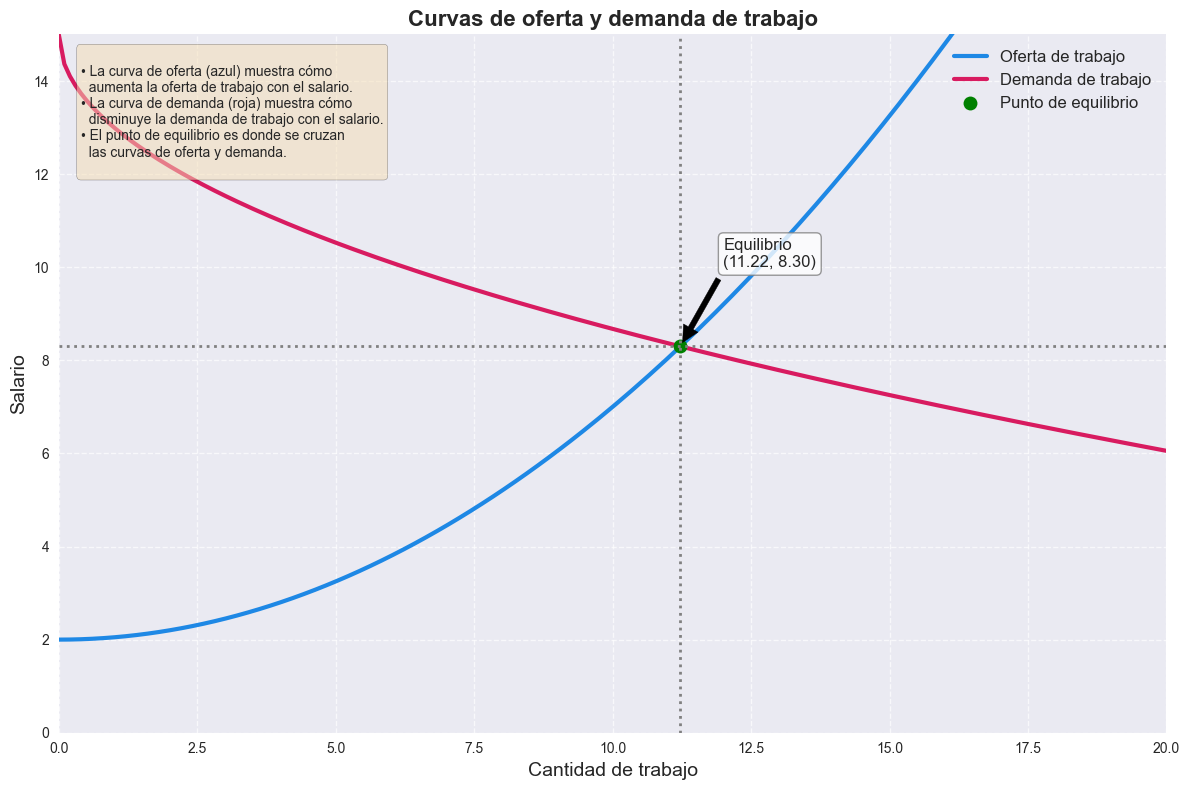

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import fsolve
import matplotlib.patches as patches

# Funciones para las curvas de oferta y demanda
def supply(x):
    return 2 + 0.05 * x**2

def demand(x):
    return 15 - 2 * np.sqrt(x)

def equilibrium(x):
    return supply(x) - demand(x)

# Generar puntos para las curvas
x = np.linspace(0, 20, 200)
y_supply = supply(x)
y_demand = demand(x)

# Encontrar el punto de equilibrio
equilibrium_x = fsolve(equilibrium, 10)[0]
equilibrium_y = supply(equilibrium_x)

# Configurar el estilo del gráfico
plt.style.use('seaborn')
fig, ax = plt.subplots(figsize=(12, 8))

# Dibujar las curvas
ax.plot(x, y_supply, label='Oferta de trabajo', color='#1e88e5', linewidth=3)
ax.plot(x, y_demand, label='Demanda de trabajo', color='#d81b60', linewidth=3)
ax.plot(equilibrium_x, equilibrium_y, 'go', markersize=10, label='Punto de equilibrio')

# Configurar los ejes
ax.set_xlim(0, 20)
ax.set_ylim(0, 15)
ax.set_xlabel('Cantidad de trabajo', fontsize=14)
ax.set_ylabel('Salario', fontsize=14)
ax.set_title('Curvas de oferta y demanda de trabajo', fontsize=16, fontweight='bold')

# Añadir una cuadrícula
ax.grid(True, linestyle='--', alpha=0.7)

# Añadir líneas punteadas para el punto de equilibrio
ax.axhline(y=equilibrium_y, color='gray', linestyle=':', linewidth=2)
ax.axvline(x=equilibrium_x, color='gray', linestyle=':', linewidth=2)

# Añadir anotación para el punto de equilibrio
ax.annotate(f'Equilibrio\n({equilibrium_x:.2f}, {equilibrium_y:.2f})',
            xy=(equilibrium_x, equilibrium_y), xytext=(12, 10),
            arrowprops=dict(facecolor='black', shrink=0.05),
            bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", lw=1, alpha=0.8),
            fontsize=12)

# Añadir leyenda
ax.legend(loc='upper right', fontsize=12)

# Añadir un recuadro explicativo
explanation = """
• La curva de oferta (azul) muestra cómo
  aumenta la oferta de trabajo con el salario.
• La curva de demanda (roja) muestra cómo
  disminuye la demanda de trabajo con el salario.
• El punto de equilibrio es donde se cruzan
  las curvas de oferta y demanda.
"""
props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)
ax.text(0.02, 0.98, explanation, transform=ax.transAxes, fontsize=10,
        verticalalignment='top', bbox=props)

plt.tight_layout()
plt.show()


C:\Users\Usuario\AppData\Local\Temp\ipykernel_41540\2769258891.py:5: MatplotlibDeprecationWarning: The seaborn styles shipped by Matplotlib are deprecated since 3.6, as they no longer correspond to the styles shipped by seaborn. However, they will remain available as 'seaborn-v0_8-<style>'. Alternatively, directly use the seaborn API instead.
  plt.style.use('seaborn')


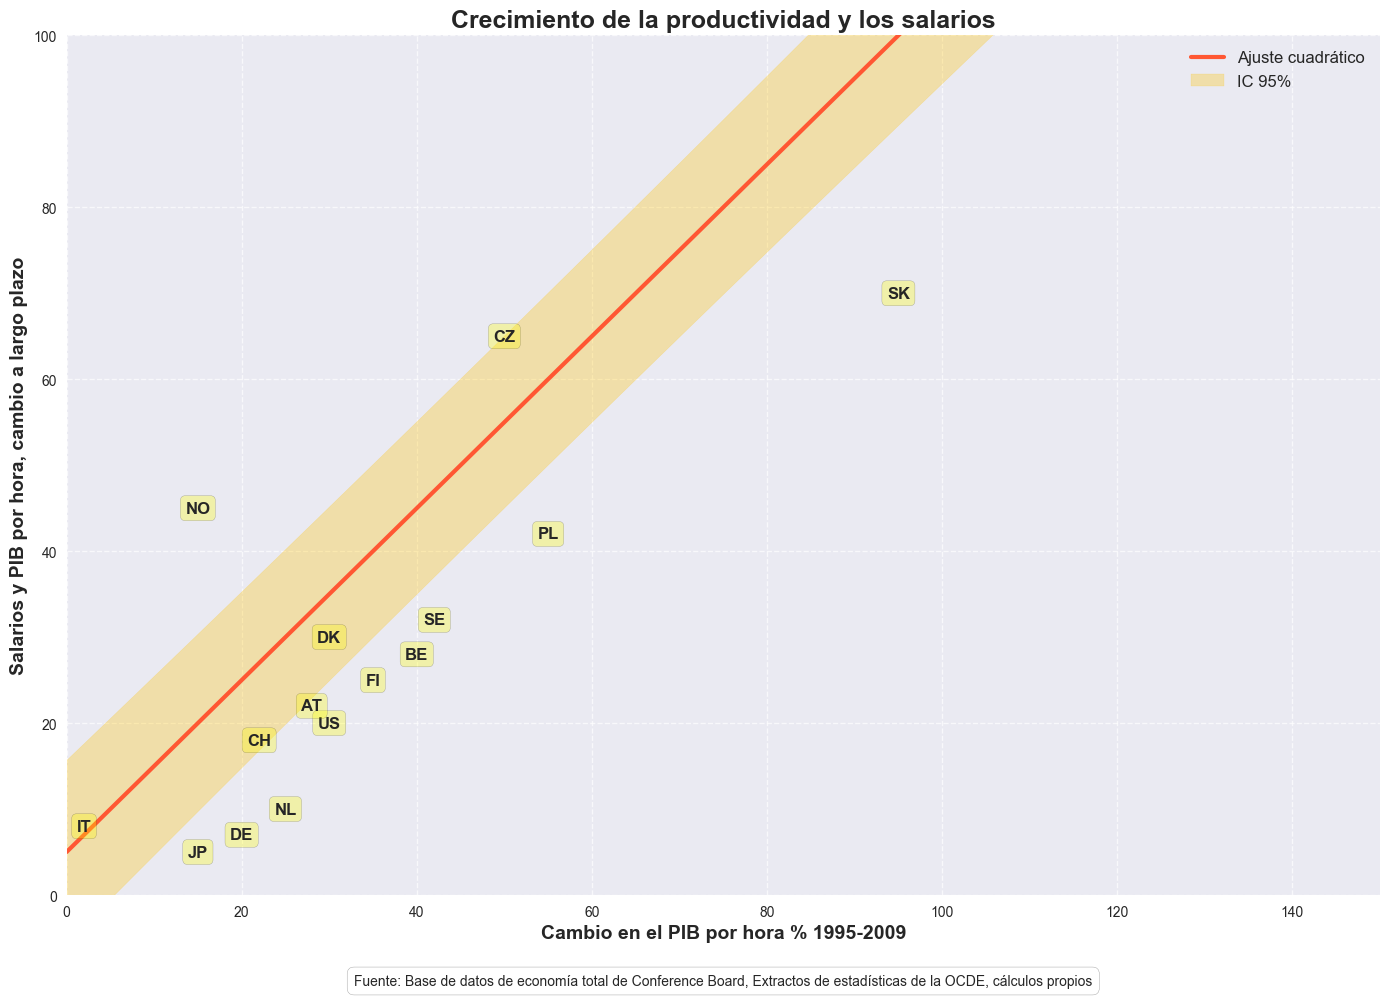

In [11]:
import matplotlib.pyplot as plt
import numpy as np

# Configurar el estilo
plt.style.use('seaborn')

# Datos para el ajuste cuadrático
x_data = np.array([0, 5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 55, 60, 65, 70, 75, 80, 85, 90, 95, 100])
y_data = np.array([5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 55, 60, 65, 70, 75, 80, 85, 90, 95, 100, 105])

# Países y sus coordenadas aproximadas
countries = {
    'IT': (2, 8), 'JP': (15, 5), 'DE': (20, 7), 'NL': (25, 10),
    'CH': (22, 18), 'US': (30, 20), 'AT': (28, 22), 'FI': (35, 25),
    'BE': (40, 28), 'SE': (42, 32), 'DK': (30, 30), 'NO': (15, 45),
    'CZ': (50, 65), 'PL': (55, 42), 'SK': (95, 70)
}

# Configurar el gráfico
fig, ax = plt.subplots(figsize=(14, 10))

# Agregar los países
for country, (x, y) in countries.items():
    ax.annotate(country, (x, y), fontsize=12, fontweight='bold', 
                bbox=dict(boxstyle="round,pad=0.3", fc="yellow", ec="black", alpha=0.3),
                ha='center', va='center')

# Ajuste cuadrático
z = np.polyfit(x_data, y_data, 2)
p = np.poly1d(z)
x_range = np.linspace(0, 150, 500)  # Extendemos el rango y aumentamos los puntos para una curva más suave
y_fit = p(x_range)
ax.plot(x_range, y_fit, color='#FF5733', linewidth=3, label="Ajuste cuadrático")

# Intervalo de confianza (simulado)
confidence = 10 * np.sqrt(1 + np.power((x_range - np.mean(x_data)) / np.std(x_data), 2) / len(x_data))
ax.fill_between(x_range, y_fit - confidence, y_fit + confidence, color='#FFC300', alpha=0.3, label="IC 95%")

# Configuración del gráfico
ax.set_xlabel('Cambio en el PIB por hora % 1995-2009', fontsize=14, fontweight='bold')
ax.set_ylabel('Salarios y PIB por hora, cambio a largo plazo', fontsize=14, fontweight='bold')
ax.set_title('Crecimiento de la productividad y los salarios', fontsize=18, fontweight='bold')
ax.set_xlim(0, 150)
ax.set_ylim(0, 100)
ax.grid(True, linestyle='--', alpha=0.7)

# Leyenda
ax.legend(fontsize=12)

# Agregar fuente
ax.text(0.5, -0.1, 'Fuente: Base de datos de economía total de Conference Board, Extractos de estadísticas de la OCDE, cálculos propios', 
        fontsize=10, ha='center', va='center', transform=ax.transAxes, wrap=True, 
        bbox=dict(boxstyle='round,pad=0.5', fc='white', ec='gray', alpha=0.8))

# Ajustar el diseño y mostrar
plt.tight_layout()
plt.show()